# MS3: Preprocessing Pipeline
Beehive Sounds Dataset — SBCM

In [1]:
import sys
sys.path.append('/home/stiwari6/.local/lib/python3.11/site-packages')

import kagglehub
import os

os.environ["KAGGLE_USERNAME"] = "snigdhatiwarisd"
os.environ["KAGGLE_KEY"] = "KGAT_b5f7b91d08ee5010cc63d7ee3b3e3170"

path = kagglehub.dataset_download("annajyang/beehive-sounds")
print("dataset path:", path)

PROJECT_DIR = os.getcwd()
csv_path  = os.path.join(path, "all_data_updated.csv")
AUDIO_DIR = os.path.join(path, "sound_files", "sound_files")

print("csv_path :", csv_path)
print("AUDIO_DIR:", AUDIO_DIR)

dataset path: /home/stiwari6/.cache/kagglehub/datasets/annajyang/beehive-sounds/versions/3
csv_path : /home/stiwari6/.cache/kagglehub/datasets/annajyang/beehive-sounds/versions/3/all_data_updated.csv
AUDIO_DIR: /home/stiwari6/.cache/kagglehub/datasets/annajyang/beehive-sounds/versions/3/sound_files/sound_files


In [2]:
# ── spark session ────────────────────────────────────────────
# SparkSession is the entry point for all Spark operations.
# Memory settings follow the formula from the assignment:
#   executor instances = total cores - 1 = 8 - 1 = 7
#   executor memory = (128GB - 2GB driver) / 7 = ~18GB each
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("BeehivePreprocessing") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", 7) \
    .getOrCreate()

# load the CSV into a Spark DataFrame
# check if df was loaded correctly
df = spark.read.csv(csv_path, header=True, inferSchema=True)
print(f"loaded {df.count()} rows, {len(df.columns)} columns")

loaded 1275 rows, 23 columns


In [3]:
# ── step 1: audio feature extraction ────────────────────────
# the dataset has two components:
#   1. CSV metadata (sensor readings, weather, queen status)
#   2. .wav audio files — the actual beehive recordings
#
# each CSV row links to multiple audio segments via the 'file name' column.
# e.g. '2022-06-08--14-52-28_1.raw' matches:
#       '2022-06-08--14-52-28_1__segment0.wav'
#       '2022-06-08--14-52-28_1__segment1.wav' etc.
#
# we use a Spark UDF (User Defined Function) to extract audio features
# from each group of segments and average them into one feature vector per row.
#
# note: we use scipy instead of librosa because librosa has a numba
# caching incompatibility with this server's conda environment.

import numpy as np
from scipy.io import wavfile
from pyspark.sql.types import StructType, StructField, DoubleType
from pyspark.sql.functions import udf

# number of MFCC coefficients to extract per audio clip
# MFCCs capture the timbral texture of sound 
N_MFCC = 13

# hardcode the audio directory path so spark executors can access it
AUDIO_DIR_CONST = AUDIO_DIR

# list of all audio feature column names we will extract in each N_MFCC
feature_keys = (
    ["rms", "spectral_centroid", "spectral_rolloff", "zero_crossing_rate"]
    + [f"mfcc_{i+1}" for i in range(N_MFCC)]
)

# define the output schema for the UDF so Spark knows what types to expect
# each feature is a DoubleType (floating point number)
feature_schema = StructType(
    [StructField(k, DoubleType(), True) for k in feature_keys]
)

# define the UDF — takes a file name string, returns a struct of audio features
# @udf decorator registers this python function as a Spark UDF
@udf(returnType=feature_schema)
def extract_audio_features(file_name):
    try:
        # imports must be inside the UDF because each spark executor
        # runs in its own process and needs its own imports
        import numpy as np
        from scipy.io import wavfile
        import os

        # strip '.raw' extension to get the base name for matching audio segments
        # e.g. '2022-06-08--14-52-28_1.raw' → '2022-06-08--14-52-28_1'
        base = file_name.replace(".raw", "")
        audio_dir = AUDIO_DIR_CONST
        n_mfcc = 13

        # find all .wav segment files that match this base recording
        segments = [
            f for f in os.listdir(audio_dir)
            if f.startswith(base + "__segment") and f.endswith(".wav")
        ]
        # if no matching audio files found (53 rows), return None
        # these nulls will be imputed later with mean values
        if not segments:
            return None

        all_feats = []
        for seg in segments:
            filepath = os.path.join(audio_dir, seg)

            # load the wav file using scipy. this returns sample rate and audio array
            sr, audio = wavfile.read(filepath)

            # if stereo (2 channels), convert to mono by averaging channels
            if audio.ndim > 1:
                audio = audio.mean(axis=1)
            n = len(audio)

            # ── rms energy ────────────────────────────────────
            # root mean square energy = overall loudness of the clip
            # louder hives may indicate different queen states
            rms = float(np.sqrt(np.mean(audio**2)))

            # ── spectral features via fft ─────────────────────
            # convert audio from time domain to frequency domain
            freqs = np.fft.rfftfreq(n, d=1/sr)
            magnitude = np.abs(np.fft.rfft(audio))
            magnitude_sum = magnitude.sum()

            # spectral centroid: weighted average frequency = "brightness" of sound
            # higher centroid = more high-frequency content in the buzz
            spectral_centroid = float(np.sum(freqs * magnitude) / magnitude_sum) if magnitude_sum > 0 else 0.0

            # spectral rolloff: frequency below which 85% of energy is concentrated
            # captures the overall frequency distribution shape
            cumsum = np.cumsum(magnitude)
            rolloff_idx = np.searchsorted(cumsum, 0.85 * magnitude_sum)
            spectral_rolloff = float(freqs[min(rolloff_idx, len(freqs)-1)])

            # zero crossing rate: how often the signal crosses zero
            # higher ZCR = noisier, more chaotic signal
            zero_crossing_rate = float(np.mean(np.abs(np.diff(np.sign(audio))) > 0))

            # ── mfcc via mel filterbank + dct ─────────────────
            # MFCCs capture the timbral texture (tone quality) of the audio
            # they are the most important features for audio classification
            n_fft = 2048   # fft window size in samples
            n_mels = 128   # number of mel frequency bands
            hop = n_fft // 2  # 50% overlap between frames

            # convert frequency range to mel scale (perceptual scale of pitch)
            mel_max = 2595 * np.log10(1 + (sr/2) / 700)
            mel_points = np.linspace(0, mel_max, n_mels + 2)
            hz_points = 700 * (10**(mel_points / 2595) - 1)
            bin_points = np.floor((n_fft + 1) * hz_points / sr).astype(int)

            # split audio into overlapping frames and compute power spectrum per frame
            frames = []
            for start in range(0, max(1, n - n_fft), hop):
                frame = audio[start:start + n_fft]
                if len(frame) < n_fft:
                    frame = np.pad(frame, (0, n_fft - len(frame)))
                frames.append(np.abs(np.fft.rfft(frame))**2)

            if not frames:
                mfccs = [0.0] * n_mfcc
            else:
                power_spec = np.array(frames)

                # apply mel filterbank: map power spectrum onto mel frequency bands
                mel_spec = np.zeros((len(frames), n_mels))
                for m in range(n_mels):
                    s, c, e = bin_points[m], bin_points[m+1], bin_points[m+2]
                    for k in range(s, c):
                        if k < power_spec.shape[1]:
                            mel_spec[:, m] += power_spec[:, k] * (k - s) / max(1, c - s)
                    for k in range(c, e):
                        if k < power_spec.shape[1]:
                            mel_spec[:, m] += power_spec[:, k] * (e - k) / max(1, e - c)

                # apply log to compress dynamic range (mimics human hearing)
                log_mel = np.log(mel_spec + 1e-9)

                # apply DCT to decorrelate the mel bands and get final MFCC coefficients
                dct_matrix = np.cos(np.pi * np.arange(n_mfcc)[:, None] *
                                   (2 * np.arange(n_mels) + 1) / (2 * n_mels))
                mfcc_matrix = dct_matrix @ log_mel.T

                # take mean of each MFCC across all frames = one value per coefficient
                mfccs = [float(np.mean(mfcc_matrix[i])) for i in range(n_mfcc)]

            # collect features for this segment
            all_feats.append((rms, spectral_centroid, spectral_rolloff,
                             zero_crossing_rate, *mfccs))

        # average features across all segments for this recording
        # each CSV row has ~6 segments — we combine them into one feature vector
        averaged = tuple(
            float(np.mean([f[i] for f in all_feats]))
            for i in range(len(all_feats[0]))
        )
        return averaged

    except Exception:
        # return None if anything fails — nulls will be imputed later
        return None

# apply the UDF to every row in the DataFrame
# this adds an 'audio_features' struct column with all 17 audio features
# spark runs this distributed across all 7 executors in parallel
print("extracting audio features via spark udf...")
df_audio = df.withColumn("audio_features", extract_audio_features(F.col("file name")))

# expand the struct column into individual columns (one per feature)
for k in feature_keys:
    df_audio = df_audio.withColumn(k, F.col(f"audio_features.{k}"))

# drop the intermediate struct column
df_combined = df_audio.drop("audio_features")

# verify the join worked. rms and mfcc_1 should have real values not NULL
df_combined.select("file name", "rms", "mfcc_1").show(5, truncate=False)
print(f"combined rows: {df_combined.count()}, columns: {len(df_combined.columns)}")

extracting audio features via spark udf...
+--------------------------+--------------------+------------------+
|file name                 |rms                 |mfcc_1            |
+--------------------------+--------------------+------------------+
|2022-06-08--14-52-28_1.raw|0.06254665801922481 |30.35206607357536 |
|2022-06-08--15-51-41_1.raw|0.07940646136800449 |58.163883430913565|
|2022-06-08--17-21-53_1.raw|0.09545838336149852 |132.73124071046982|
|2022-06-08--18-20-59_1.raw|0.04471157739559809 |15.399691062313932|
|2022-06-08--19-20-04_1.raw|0.046058149387439094|33.307730766198105|
+--------------------------+--------------------+------------------+
only showing top 5 rows

combined rows: 1275, columns: 40


In [4]:
# ── step 2: preprocessing pipeline ──────────────────────────
from pyspark.ml.feature import Imputer, StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

# ── 2a: drop useless columns ─────────────────────────────────
# gust speed:  994/1275 nulls (77.96%) — too sparse to use
# lat/long:    stddev = 0.0 — every row has the same value, adds no information
# rain:        always 0 across all rows — zero variance, adds no information
# file name:   identifier string, not a feature for modeling
df_clean = df_combined.drop("gust speed", "lat", "long", "rain", "file name")
print(f"after dropping useless columns: {len(df_clean.columns)} columns")

# ── 2b: feature engineering from date column ─────────────────
# the raw 'date' column is a timestamp which is not directly usable by ML models
# we extract meaningful time components that may correlate with bee behavior: hour, month, day of week
# F.hour(), F.month(), F.dayofweek() are Spark SQL functions
df_clean = df_clean \
    .withColumn("hour", F.hour("date")) \
    .withColumn("month", F.month("date")) \
    .withColumn("day_of_week", F.dayofweek("date")) \
    .drop("date")
print("date features extracted: hour, month, day_of_week")

# ── 2c: impute missing sensor values ─────────────────────────
# weather temp and wind speed each have 4 null values 
# use strategy='mean': replace nulls with the column average
# this is fine since only 4 rows are affected out of 1275
imputer = Imputer(
    inputCols=["weather temp", "wind speed"],
    outputCols=["weather temp", "wind speed"],
    strategy="mean"
)

df_clean = imputer.fit(df_clean).transform(df_clean)
print("sensor null imputation done")

# ── 2d: encode categorical columns ───────────────────────────
# ML models need numbers — categorical columns must be converted
# we use a two-step processs: StringIndexer nad OneHotEncoder
cols_to_encode = ["weatherID", "device", "hive number"]

# apply StringIndexer for each categorical column and if unseen values appear, keep them as a separate category
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
    for c in cols_to_encode
]
for indexer in indexers:
    df_clean = indexer.fit(df_clean).transform(df_clean)

# apply OneHotEncoder to all indexed columns at once
encoder = OneHotEncoder(
    inputCols=[f"{c}_index" for c in cols_to_encode],
    outputCols=[f"{c}_encoded" for c in cols_to_encode]
)
df_clean = encoder.fit(df_clean).transform(df_clean)


df_clean = df_clean.drop(
    *cols_to_encode,
    *[f"{c}_index" for c in cols_to_encode]
)
print("categorical encoding done: weatherID, device, hive number")

# ── 2e: impute null audio features ───────────────────────────
# 53 CSV rows had no matching audio files so their audio features are null
# we impute these with column means so no rows are dropped from the dataset
AUDIO_COLS = (
    ["rms", "spectral_centroid", "spectral_rolloff", "zero_crossing_rate"]
    + [f"mfcc_{i+1}" for i in range(N_MFCC)]
)
audio_imputer = Imputer(
    inputCols=AUDIO_COLS,
    outputCols=AUDIO_COLS,
    strategy="mean"
)
df_clean = audio_imputer.fit(df_clean).transform(df_clean)
print("audio null imputation done")

# ── 2f: assemble all features into one vector ─────────────────
# Spark ML models require all features in a single vector column
# VectorAssembler combines all feature columns into one 'features_raw' column
SENSOR_COLS = [
    "hive temp", "hive humidity", "hive pressure",
    "weather temp", "weather humidity", "weather pressure",
    "wind speed", "cloud coverage", "frames", "time",
    "hour", "month", "day_of_week"
]
ENCODED_COLS = [f"{c}_encoded" for c in cols_to_encode]
ALL_FEATURE_COLS = AUDIO_COLS + SENSOR_COLS + ENCODED_COLS

# handleInvalid='keep': replace any remaining nulls with 0 instead of dropping rows
assembler = VectorAssembler(
    inputCols=ALL_FEATURE_COLS,
    outputCol="features_raw",
    handleInvalid="keep"
)
df_assembled = assembler.transform(df_clean)

# ── 2g: scale features ───────────────────────────────────────
# different features have very different scales:
#   hive temp: 15–55, mfcc_1: -200 to 200, cloud coverage: 0–100
# StandardScaler normalizes all features to mean=0, std=1
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

df_scaled = scaler.fit(df_assembled).transform(df_assembled)

# df_final is what gets passed to the ML model 
df_final = df_scaled.select("features", "target")

# cache df_final in memory so subsequent operations don't recompute everything
df_final.cache()
df_final.count()  
print("done!")
df_final.show(5, truncate=True)

after dropping useless columns: 35 columns
date features extracted: hour, month, day_of_week
sensor null imputation done
categorical encoding done: weatherID, device, hive number
audio null imputation done
done!
+--------------------+------+
|            features|target|
+--------------------+------+
|[-1.6508247566337...|     0|
|[-1.6492951843369...|     0|
|[-1.6478389054776...|     1|
|[-1.6524428090313...|     1|
|[-1.6523206439519...|     1|
+--------------------+------+
only showing top 5 rows



In [5]:
# ── step 3: verify output ────────────────────────────────────
import numpy as np

# grab the first row's feature vector and inspect it
sample = df_final.first()["features"]
print(f"total features per row: {len(sample)}")  # should be 30
print(f"any NaN in first row:   {any(np.isnan(v) for v in sample)}")  # should be False
print(f"feature preview:        {list(sample[:5])}")

# confirm class distribution is still correct after preprocessing
# all 1275 rows should be present with the same distribution as the original data
print("\nclass distribution after preprocessing:")
df_final.groupBy("target").count().orderBy("target").show()

total features per row: 45
any NaN in first row:   False
feature preview:        [-1.6508247566337158, -1.180087019207019, -1.1164195151072234, -1.4654649733453813, -1.8849899912295758]

class distribution after preprocessing:
+------+-----+
|target|count|
+------+-----+
|     0|  111|
|     1|   78|
|     2|   91|
|     3|  368|
|     4|  168|
|     5|  459|
+------+-----+



In [6]:
# ── step 4: handle class imbalance with class weights ────────
# the target column is heavily imbalanced:
#   class 5 = 36% of data (dominant)
#   class 1 = 6.12% of data (minority)
# without handling this, the model will be biased toward predicting class 5
#
# class weights give minority classes higher importance during training
# formula: weight = total_rows / (num_classes * class_count)
# minority classes get higher weights, dominant classes get lower weights

class_counts = df_final.groupBy("target").count().collect()
total = df_final.count()
n_classes = len(class_counts)

class_weights = {
    row["target"]: round(total / (n_classes * row["count"]), 4)
    for row in class_counts
}
print("class weights:", class_weights)
# class 1 (minority) will have the highest weight
# class 5 (dominant) will have the lowest weight

# create a mapping from target class -> weight value using Spark's create_map
weight_map = F.create_map(
    *[item for pair in
      [(F.lit(k), F.lit(v)) for k, v in class_weights.items()]
      for item in pair]
)

# add a 'weight' column by looking up each row's target in the weight map
df_final = df_final.withColumn("weight", weight_map[F.col("target")])
df_final.show(5, truncate=True)
print("preprocessing complete — df_final ready for modeling")

class weights: {1: 2.7244, 3: 0.5774, 5: 0.463, 4: 1.2649, 2: 2.3352, 0: 1.9144}
+--------------------+------+------+
|            features|target|weight|
+--------------------+------+------+
|[-1.6508247566337...|     0|1.9144|
|[-1.6492951843369...|     0|1.9144|
|[-1.6478389054776...|     1|2.7244|
|[-1.6524428090313...|     1|2.7244|
|[-1.6523206439519...|     1|2.7244|
+--------------------+------+------+
only showing top 5 rows

preprocessing complete — df_final ready for modeling


In [7]:
# ── step 5: train/test split ─────────────────────────────────
# 80/20 random split with a fixed seed for reproducibility.

train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)
train_df.cache(); test_df.cache()

print(f"train rows: {train_df.count()}")
print(f"test rows:  {test_df.count()}")

# sanity-check that class distribution is preserved in both splits
print("\ntrain class distribution:")
train_df.groupBy("target").count().orderBy("target").show()
print("test class distribution:")
test_df.groupBy("target").count().orderBy("target").show()

train rows: 1053
test rows:  222

train class distribution:
+------+-----+
|target|count|
+------+-----+
|     0|   92|
|     1|   65|
|     2|   79|
|     3|  289|
|     4|  143|
|     5|  385|
+------+-----+

test class distribution:
+------+-----+
|target|count|
+------+-----+
|     0|   19|
|     1|   13|
|     2|   12|
|     3|   79|
|     4|   25|
|     5|   74|
+------+-----+



In [8]:
# ── step 6: train baseline decision tree ─────────────────────
# We will be using a DecisionTreClassifier
# weightCol="weight" applies the per-row class weights we computed earlier,
# so the tree doesn't just learn to always predict class 5.
#
# maxDepth=5 is a sensible starting point — deep enough to capture useful
# splits, shallow enough to not memorize the 1020 training rows.

from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="target",
    weightCol="weight",
    maxDepth=5,
    seed=42,
)

dt_model = dt.fit(train_df)
print(f"trained decision tree — depth={dt_model.depth}, nodes={dt_model.numNodes}")

trained decision tree — depth=5, nodes=35


In [9]:
# ── step 7: evaluate train vs validation error ──────────────
# We report:
#   - accuracy:      fraction of correct predictions
#   - weighted F1:   harmonic mean of precision/recall, accounts for imbalance
#   - error rate:    1 - accuracy, the quantity we want to minimize

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

acc_eval = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="accuracy")
f1_eval  = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="f1")

train_pred = dt_model.transform(train_df)
test_pred  = dt_model.transform(test_df)

train_acc = acc_eval.evaluate(train_pred)
test_acc  = acc_eval.evaluate(test_pred)
train_f1  = f1_eval.evaluate(train_pred)
test_f1   = f1_eval.evaluate(test_pred)

print(f"{'':12s} {'train':>10s} {'test':>10s} {'gap':>10s}")
print(f"{'accuracy':12s} {train_acc:10.4f} {test_acc:10.4f} {train_acc - test_acc:10.4f}")
print(f"{'f1':12s} {train_f1:10.4f} {test_f1:10.4f} {train_f1 - test_f1:10.4f}")
print(f"{'error rate':12s} {1-train_acc:10.4f} {1-test_acc:10.4f} {(1-test_acc) - (1-train_acc):10.4f}")

                  train       test        gap
accuracy         0.8813     0.8829    -0.0016
f1               0.8824     0.8857    -0.0033
error rate       0.1187     0.1171    -0.0016


In [10]:
# ── step 8: confusion matrix on validation set ───────────────
# a single accuracy number hides per-class performance. the confusion matrix
# shows which classes get confused with which, being useful for an imbalanced
# problem like this where naive accuracy can be misleading.

import pandas as pd

cm = (test_pred
      .groupBy("target", "prediction")
      .count()
      .toPandas()
      .pivot(index="target", columns="prediction", values="count")
      .fillna(0)
      .astype(int))
print("confusion matrix on test set (rows = true class, cols = predicted class):")
print(cm)

confusion matrix on test set (rows = true class, cols = predicted class):
prediction  0.0  1.0  2.0  3.0  4.0  5.0
target                                  
0            10    0    0    0    8    1
1             1   12    0    0    0    0
2             0    3    9    0    0    0
3             0    3    4   72    0    0
4             0    0    0    0   25    0
5             0    0    0    0    6   68


In [11]:
# ── step 9: sweep maxDepth on the train/test split ───────────
# For each candidate maxDepth, fit a tree on train_df and score it on both
# train_df and test_df. As depth grows, training error keeps falling, 
# but test error first falls and eventually rises or flattens.

depths = [1, 2, 3, 5, 7, 10, 15]

train_errs = []
test_errs  = []

for d in depths:
    dt_d = DecisionTreeClassifier(
        featuresCol="features", labelCol="target", weightCol="weight",
        maxDepth=d, seed=42,
    )
    model_d = dt_d.fit(train_df)

    train_acc_d = acc_eval.evaluate(model_d.transform(train_df))
    test_acc_d  = acc_eval.evaluate(model_d.transform(test_df))

    train_errs.append(1 - train_acc_d)
    test_errs.append(1 - test_acc_d)
    print(f"depth={d:2d}  train_err={1-train_acc_d:.4f}  test_err={1-test_acc_d:.4f}  gap={test_acc_d - train_acc_d:+.4f}")

best_idx = int(min(range(len(depths)), key=lambda i: test_errs[i]))
print(f"\nlowest test error at depth: {depths[best_idx]} (test_err={test_errs[best_idx]:.4f})")

depth= 1  train_err=0.7892  test_err=0.8333  gap=-0.0442
depth= 2  train_err=0.2925  test_err=0.2703  gap=+0.0222
depth= 3  train_err=0.2498  test_err=0.2477  gap=+0.0020
depth= 5  train_err=0.1187  test_err=0.1171  gap=+0.0016
depth= 7  train_err=0.0313  test_err=0.0450  gap=-0.0137
depth=10  train_err=0.0019  test_err=0.0405  gap=-0.0386
depth=15  train_err=0.0000  test_err=0.0405  gap=-0.0405

lowest test error at depth: 10 (test_err=0.0405)


Matplotlib created a temporary cache directory at /scratch/stiwari6/job_49854504/matplotlib-e9unkyz5 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


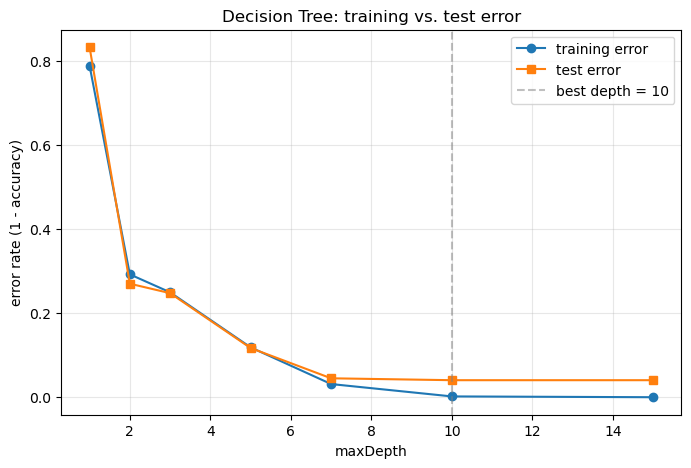

In [12]:
# ── step 10: plot the fitting curve (train vs test error) ────

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(depths, train_errs, marker="o", label="training error")
plt.plot(depths, test_errs,  marker="s", label="test error")
plt.axvline(depths[best_idx], color="grey", linestyle="--", alpha=0.5,
            label=f"best depth = {depths[best_idx]}")
plt.xlabel("maxDepth")
plt.ylabel("error rate (1 - accuracy)")
plt.title("Decision Tree: training vs. test error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# ── step 11: final summary at the best-performing depth ──────
best_depth = depths[best_idx]
final_dt = DecisionTreeClassifier(
    featuresCol="features", labelCol="target", weightCol="weight",
    maxDepth=best_depth, seed=42,
).fit(train_df)

final_train_acc = acc_eval.evaluate(final_dt.transform(train_df))
final_test_acc  = acc_eval.evaluate(final_dt.transform(test_df))
final_train_f1  = f1_eval.evaluate(final_dt.transform(train_df))
final_test_f1   = f1_eval.evaluate(final_dt.transform(test_df))

print(f"final decision tree (maxDepth={best_depth}):")
print(f"  train accuracy = {final_train_acc:.4f}   test accuracy = {final_test_acc:.4f}")
print(f"  train f1       = {final_train_f1:.4f}   test f1       = {final_test_f1:.4f}")
print(f"  generalization gap (train - test acc) = {final_train_acc - final_test_acc:.4f}")

final decision tree (maxDepth=10):
  train accuracy = 0.9981   test accuracy = 0.9595
  train f1       = 0.9981   test f1       = 0.9582
  generalization gap (train - test acc) = 0.0386


In [14]:
# ── save preprocessed splits to parquet ──────────────────────
# run this once after MS3 completes so PCA.ipynb can load directly
# without re-running the slow audio UDF
SAVE_DIR = os.path.join(PROJECT_DIR, "preprocessed")

train_df.write.mode("overwrite").parquet(f"{SAVE_DIR}/train")
test_df.write.mode("overwrite").parquet(f"{SAVE_DIR}/test")
print(f"saved to {SAVE_DIR}")

saved to /expanse/lustre/projects/uci157/stiwari6/preprocessed
